# Part 1b — Independent Data Validation (FMP vs Yahoo Finance)

Before trusting the dataset we cross-check it against a second, independent vendor
(Yahoo Finance via `yfinance`). Adjusted *price levels* are not comparable across
vendors (each normalises to its own latest price), so we compare **monthly total
returns**, which are invariant to the adjustment base. Large return gaps expose the
data hazards that matter: missed splits/dividends, bad ticks, and ticker recycling.

> Yahoo's *fundamentals* are too shallow/recent for a real historical comparison, so the
> rigorous cross-check is on prices/returns — which is also where data bugs live.

In [1]:
import pandas as pd
from IPython.display import Image
from qfr.utils.config import settings, PROJECT_ROOT

P = settings.processed_dir
CHARTS = PROJECT_ROOT / 'charts'
obs = pd.read_parquet(P / 'yahoo_validation_obs.parquet')
rep = pd.read_parquet(P / 'yahoo_validation_by_symbol.parquet')
raw = pd.read_parquet(P / 'master_pit.parquet')
clean = pd.read_parquet(P / 'master_clean.parquet')
print(f'symbols compared : {rep.ret_corr.notna().sum()}')
print(f'symbol-months    : {len(obs):,}')

symbols compared : 630
symbol-months    : 119,100


## 1. Headline: the data agrees

Across the universe, FMP and Yahoo monthly returns line up almost perfectly: the bulk of
symbols correlate above 0.99 and the median monthly difference is ~0.14%.

In [2]:
print(f'symbols with return corr >= 0.99 : {(rep.ret_corr >= 0.99).mean():.1%}')
print(f'median monthly |return diff|     : {obs.abs_ret_diff.median():.4f}')
print(f'observations within 0.5%/month   : {(obs.abs_ret_diff <= 0.005).mean():.1%}')

symbols with return corr >= 0.99 : 89.3%
median monthly |return diff|     : 0.0014
observations within 0.5%/month   : 70.2%


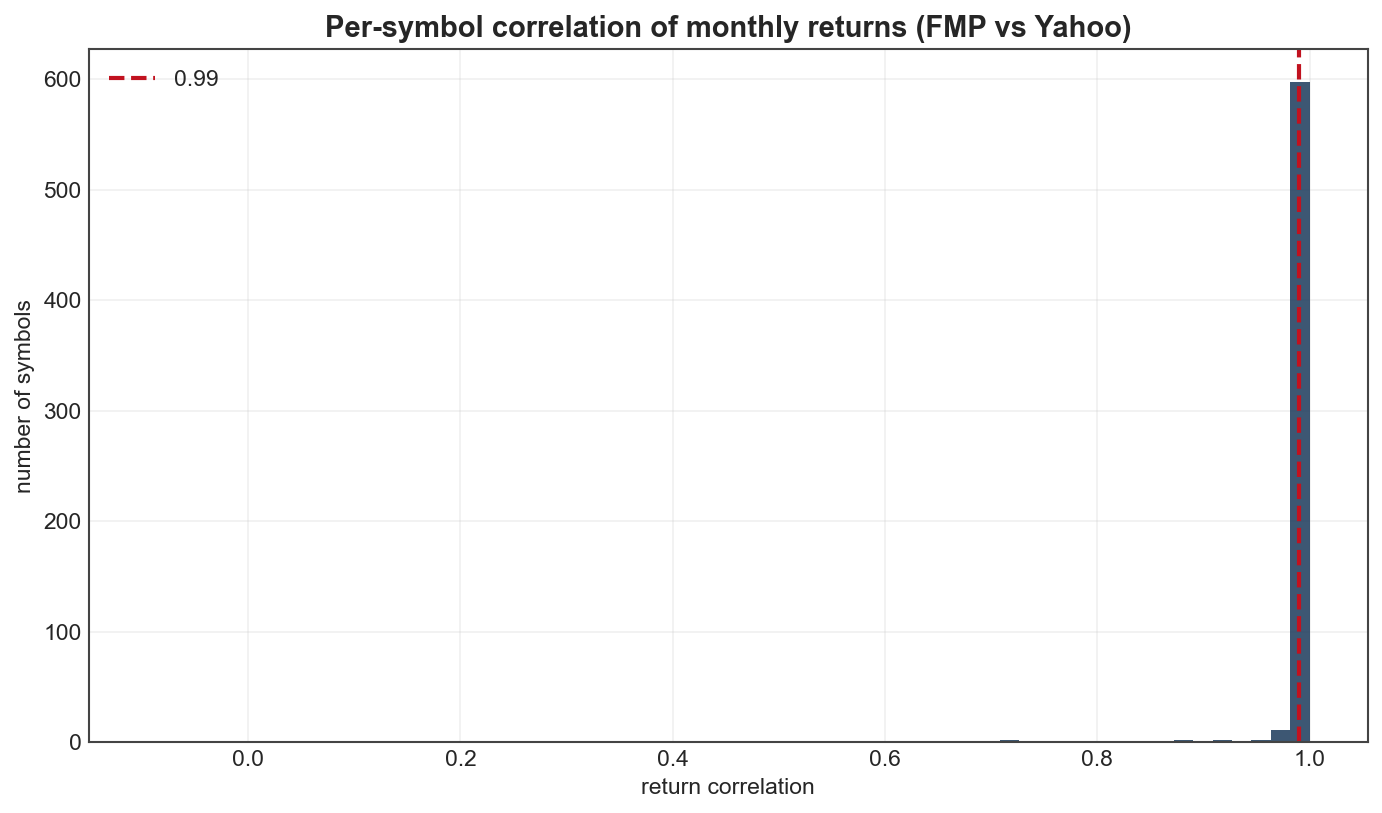

In [3]:
Image(filename=str(CHARTS / '02_return_corr_dist.png'))

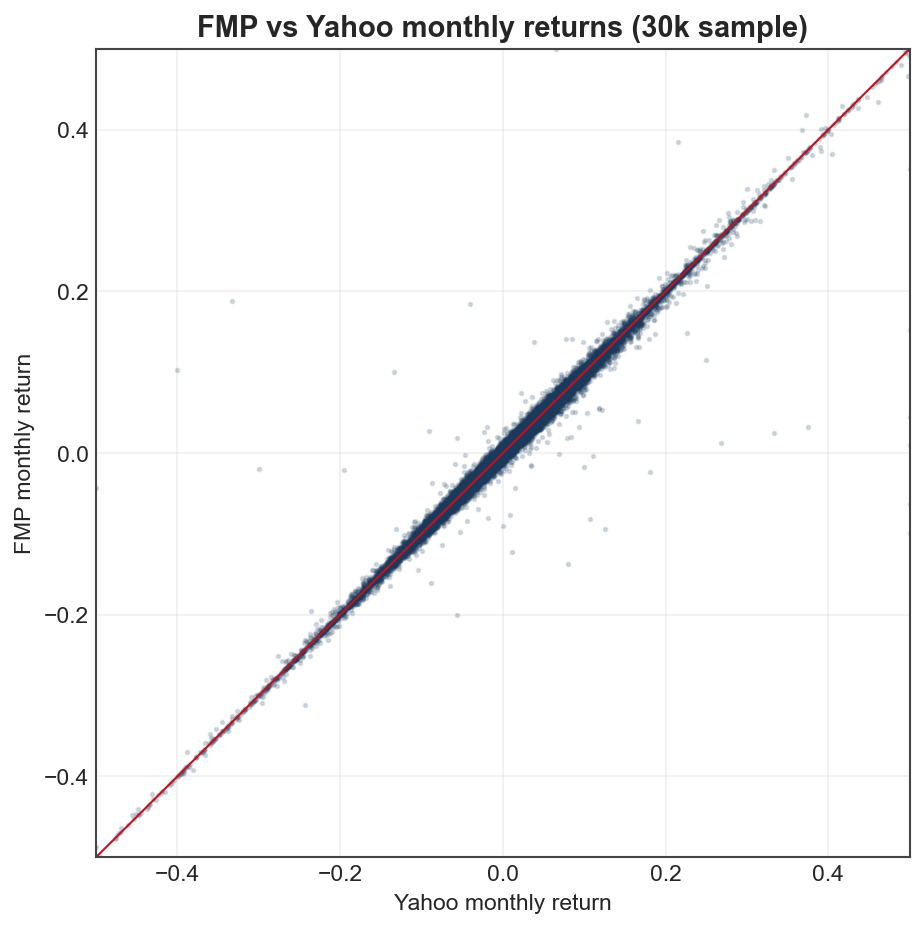

In [4]:
Image(filename=str(CHARTS / '02_fmp_vs_yahoo_scatter.png'))

## 2. Coverage — where Yahoo can't help

Yahoo silently drops delisted tickers, so it has **no data for ~112 names** that FMP
retains. These are exactly the survivorship-critical stocks — confirming FMP is the better
source for point-in-time work, and that price errors on those names can only be caught by
winsorisation, not by Yahoo.

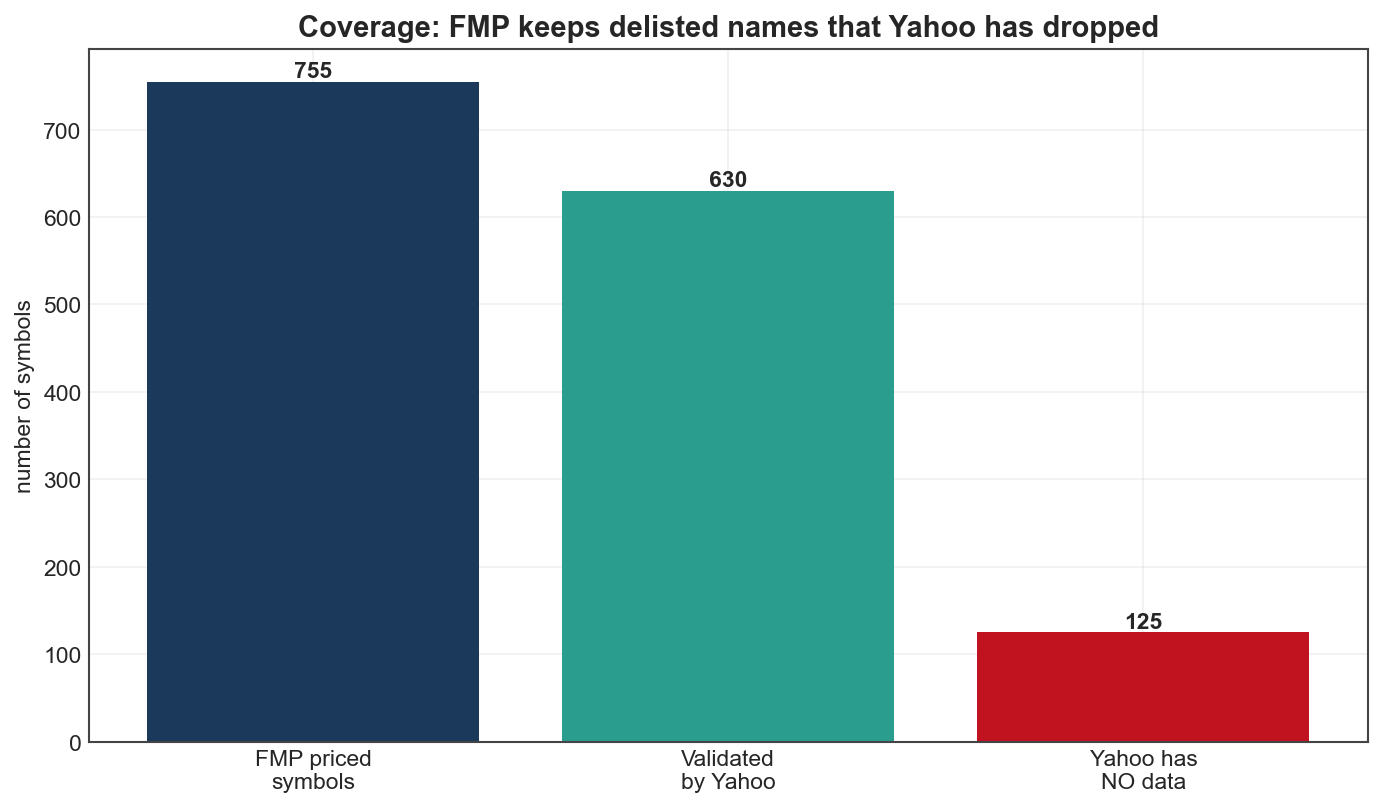

In [5]:
Image(filename=str(CHARTS / '02_coverage_comparison.png'))

## 3. The big discrepancies

Only **41 symbols** are flagged (return corr < 0.95 or a single month off by > 10%). They
fall into three buckets: corporate-action back-adjustment, corrupted FMP series, and ticker
mismatches.

In [6]:
cols = ['n_months','ret_corr','median_abs_ret_diff','max_abs_ret_diff']
rep.sort_values('max_abs_ret_diff', ascending=False).head(15)[['symbol'] + cols].round(4)

,symbol,n_months,ret_corr,median_abs_ret_diff,max_abs_ret_diff
0,FMC,209,0.9138,0.0019,34.2969
1,FIS,233,-0.0953,0.0025,4.4545
2,CPWR,59,0.0147,0.3109,3.1242
3,WEN,103,0.3428,0.0013,2.2907
4,MO,315,0.4218,0.0115,2.0504
5,EXPE,222,0.6518,0.0003,1.6953
6,WY,315,0.5916,0.0063,1.6598
7,ROK,313,0.7100,0.0044,1.5995
8,MDLZ,229,0.2202,0.0050,1.3542
9,JCI,298,0.7808,0.0050,1.2515


### Case studies
- **CPWR** — FMP adjusted prices ~$1,000 vs Yahoo ~$2–6 (a ~200x error); correlation ~0.
  *Corrupted series → excluded entirely.*
- **FMC** — a single month (2009-08) shows a +3,680% FMP return vs +251% Yahoo; the rest
  matches. *Isolated bad tick → that month nulled.*
- **MO** — 2008 Philip Morris spin-off, adjusted differently by each vendor.
  *Legitimate corporate action → symbol kept, the distorted month nulled.*

In [7]:
for sym in ['CPWR','FMC','MO']:
    d = obs[obs.symbol == sym].sort_values('abs_ret_diff', ascending=False).head(3)
    print('=' * 64); print(sym)
    print(d[['ym','adjClose','y_adjclose','fmp_ret','y_ret','ret_diff']].to_string(index=False))

CPWR
     ym  adjClose  y_adjclose   fmp_ret    y_ret  ret_diff
2011-08    975.65    2.306709 -0.124239 3.000002 -3.124241
2010-10   1154.41    6.343450  0.174888 1.750000 -1.575112
2011-06   1125.58    0.576677 -0.042206 1.380956 -1.423162
FMC
     ym  adjClose  y_adjclose   fmp_ret    y_ret  ret_diff
2009-08     15.42   15.437352 36.808018 2.511120 34.296898
2025-01     52.77   52.773079  0.147673 0.161404 -0.013731
2024-03     58.41   57.879635  0.140375 0.129633  0.010742
MO
     ym  adjClose  y_adjclose   fmp_ret     y_ret  ret_diff
2008-04      6.50    6.497817 -0.098474  1.951946 -2.050420
2008-03      7.21    2.201198 -0.005517 -0.696473  0.690955
2007-05      6.84    6.836443  0.031674  0.374600 -0.342926


## 4. Conservative remediation

Policy (`qfr.data.clean`): exclude only genuinely corrupted series; null the individual
bad/ambiguous months (bad ticks + spin-off months) while **keeping** those symbols; recompute
forward returns on the cleaned price panel. Output: `master_clean.parquet` — the canonical
panel for Parts 2+. The footprint is deliberately tiny.

In [8]:
print(f'symbols excluded (corrupted) : {clean.loc[clean.excluded_corrupted, "symbol"].nunique()}')
print(f'months nulled (suspect)      : {int(clean.suspect_month.sum())}')
print(f'investable rows: {int(raw.investable.sum()):,} (raw) -> {int(clean.investable.sum()):,} (clean)')
removed = int(raw.investable.sum()) - int(clean.investable.sum())
print(f'net investable removed       : {removed:,}  ({removed / int(raw.investable.sum()):.2%})')

symbols excluded (corrupted) : 1
months nulled (suspect)      : 38
investable rows: 130,817 (raw) -> 130,737 (clean)
net investable removed       : 80  (0.06%)


## Conclusion

Independent cross-validation confirms the FMP price data is sound (>89% of symbols correlate
≥0.99 with Yahoo), isolates a small set of explainable discrepancies, and removes the few
genuinely bad cells. **`master_clean.parquet` is the dataset used from here on.**

**Next — Part 2 (EDA):** distributions, skew, outliers and rolling behaviour of the inputs.